# 3일차: 하이퍼파라미터 튜닝 및 XAI(설명 가능한 AI)

## 학습 목표
- GridSearchCV와 Optuna를 사용한 하이퍼파라미터 최적화
- SHAP을 활용한 모델 해석 및 Feature Importance 분석
- LIME을 통한 개별 예측 설명
- 최적화된 모델의 성능 개선 확인

---

## 1. 라이브러리 Import 및 데이터 준비

In [5]:
pip install optuna shap lime

Note: you may need to restart the kernel to use updated packages.


In [6]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")
import os
import pickle

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

# scikit-learn
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import make_scorer, classification_report
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 하이퍼파라미터 튜닝
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

optuna.logging.set_verbosity(optuna.logging.WARNING)

# XAI 라이브러리
import shap
import lime
import lime.lime_tabular

print("모든 라이브러리가 성공적으로 로드되었습니다.")

모든 라이브러리가 성공적으로 로드되었습니다.


In [7]:
# 데이터 로드
df = pd.read_csv("data/ai4i2020.csv")

# XGBoost 호환을 위한 컬럼명 변경 (대괄호 제거) - 1일차와 동일
column_rename_map = {
    "Air temperature [K]": "Air_temperature_K",
    "Process temperature [K]": "Process_temperature_K",
    "Rotational speed [rpm]": "Rotational_speed_rpm",
    "Torque [Nm]": "Torque_Nm",
    "Tool wear [min]": "Tool_wear_min",
}
df.rename(columns=column_rename_map, inplace=True)

# 특성 선택
features_to_use = [
    "Type",
    "Air_temperature_K",
    "Process_temperature_K",
    "Rotational_speed_rpm",
    "Torque_Nm",
    "Tool_wear_min",
]
target = "Machine failure"

X = df[features_to_use].copy()
y = df[target].copy()

# Type 인코딩
le = LabelEncoder()
X["Type_encoded"] = le.fit_transform(X["Type"])
X = X.drop("Type", axis=1)

# Feature Engineering - 새로운 특성 추가
X["Temperature_diff"] = X["Process_temperature_K"] - X["Air_temperature_K"]
X["Power"] = X["Rotational_speed_rpm"] * X["Torque_Nm"] / 9549  # 기계적 파워 계산
X["Wear_torque_interaction"] = X["Tool_wear_min"] * X["Torque_Nm"]

print("Feature Engineering 완료!")
print(f"새로운 특성 포함 총 특성 수: {X.shape[1]}")

# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# DataFrame으로 변환 (특성명 유지)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"\n학습 데이터: {X_train_scaled.shape}")
print(f"테스트 데이터: {X_test_scaled.shape}")
print("\n⚠️ XGBoost 호환을 위해 컬럼명의 대괄호를 언더스코어로 변경했습니다.")

Feature Engineering 완료!
새로운 특성 포함 총 특성 수: 9

학습 데이터: (8000, 9)
테스트 데이터: (2000, 9)

⚠️ XGBoost 호환을 위해 컬럼명의 대괄호를 언더스코어로 변경했습니다.


## 1.1 1일차 모델 불러오기 (선택사항)

In [8]:
# 1일차 모델 불러오기 (선택사항)
print("=== 1일차 모델 불러오기 ===")

# Type 인코딩 (1일차와 동일)
df_basic = df.copy()
le_basic = LabelEncoder()
df_basic["Type_encoded"] = le_basic.fit_transform(df_basic["Type"])

# Feature Engineering 없는 데이터 준비 (1일차와 동일한 특성)
X_basic = df_basic[
    [
        "Type_encoded",
        "Air_temperature_K",
        "Process_temperature_K",
        "Rotational_speed_rpm",
        "Torque_Nm",
        "Tool_wear_min",
    ]
].copy()

# Train/Test 분할 (1일차와 동일)
X_train_basic, X_test_basic, _, _ = train_test_split(
    X_basic, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링 (1일차와 동일)
scaler_basic = StandardScaler()
X_train_basic_scaled = scaler_basic.fit_transform(X_train_basic)
X_test_basic_scaled = scaler_basic.transform(X_test_basic)

if os.path.exists("models/rf_model.pkl") and os.path.exists("models/xgb_model.pkl"):
    # 저장된 모델 로드
    with open("models/rf_model.pkl", "rb") as f:
        rf_model_1day = pickle.load(f)
    with open("models/xgb_model.pkl", "rb") as f:
        xgb_model_1day = pickle.load(f)
    print("✅ 1일차 모델을 성공적으로 불러왔습니다.")

    # 테스트 데이터에 대해 예측 수행
    rf_pred_1day = rf_model_1day.predict(X_test_basic_scaled)
    xgb_pred_1day = xgb_model_1day.predict(X_test_basic_scaled)

    # 성능 메트릭 계산
    print("\n=== 1일차 모델 성능 (테스트 데이터) ===")
    print("Random Forest:")
    print(f"  Accuracy:  {accuracy_score(y_test, rf_pred_1day):.4f}")
    print(f"  Precision: {precision_score(y_test, rf_pred_1day):.4f}")
    print(f"  Recall:    {recall_score(y_test, rf_pred_1day):.4f}")
    print(f"  F1-Score:  {f1_score(y_test, rf_pred_1day):.4f}")

    print("\nXGBoost:")
    print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred_1day):.4f}")
    print(f"  Precision: {precision_score(y_test, xgb_pred_1day):.4f}")
    print(f"  Recall:    {recall_score(y_test, xgb_pred_1day):.4f}")
    print(f"  F1-Score:  {f1_score(y_test, xgb_pred_1day):.4f}")

else:
    print("⚠️ 1일차 모델 파일이 없습니다. 1일차 노트북을 실행하여 모델을 저장해주세요.")
    print("   models/rf_model.pkl")
    print("   models/xgb_model.pkl")

=== 1일차 모델 불러오기 ===
✅ 1일차 모델을 성공적으로 불러왔습니다.

=== 1일차 모델 성능 (테스트 데이터) ===
Random Forest:
  Accuracy:  0.8885
  Precision: 0.0468
  Recall:    0.1176
  F1-Score:  0.0669

XGBoost:
  Accuracy:  0.8830
  Precision: 0.0440
  Recall:    0.1176
  F1-Score:  0.0640


## 2. 하이퍼파라미터 튜닝 소개

### 2.1 하이퍼파라미터 튜닝의 중요성

In [9]:
print("=== 하이퍼파라미터 튜닝 방법 비교 ===")
print()
print("1. Grid Search")
print("   - 장점: 모든 조합을 탐색하여 최적값 보장")
print("   - 단점: 계산 비용이 높음 (파라미터 수가 늘어나면 기하급수적 증가)")
print("   - 사용 시기: 파라미터가 적고 범위가 작을 때")
print()
print("2. Random Search")
print("   - 장점: Grid Search보다 빠르고 효율적")
print("   - 단점: 최적값을 놓칠 가능성 존재")
print("   - 사용 시기: 파라미터가 많고 탐색 공간이 클 때")
print()
print("3. Bayesian Optimization (Optuna)")
print("   - 장점: 이전 시도를 학습하여 효율적 탐색")
print("   - 단점: 구현이 복잡하고 설정이 필요")
print("   - 사용 시기: 복잡한 모델의 최적화가 필요할 때")

=== 하이퍼파라미터 튜닝 방법 비교 ===

1. Grid Search
   - 장점: 모든 조합을 탐색하여 최적값 보장
   - 단점: 계산 비용이 높음 (파라미터 수가 늘어나면 기하급수적 증가)
   - 사용 시기: 파라미터가 적고 범위가 작을 때

2. Random Search
   - 장점: Grid Search보다 빠르고 효율적
   - 단점: 최적값을 놓칠 가능성 존재
   - 사용 시기: 파라미터가 많고 탐색 공간이 클 때

3. Bayesian Optimization (Optuna)
   - 장점: 이전 시도를 학습하여 효율적 탐색
   - 단점: 구현이 복잡하고 설정이 필요
   - 사용 시기: 복잡한 모델의 최적화가 필요할 때


## 3. GridSearchCV를 사용한 XGBoost 튜닝

### 3.1 기본 모델 성능 확인

In [10]:
# 기본 XGBoost 모델
base_xgb = xgb.XGBClassifier(
    random_state=42, use_label_encoder=False, eval_metric="logloss"
)

# 학습 및 예측
base_xgb.fit(X_train_scaled, y_train)
base_pred = base_xgb.predict(X_test_scaled)

# 성능 평가
print("=== 기본 XGBoost 모델 성능 ===")
print(f"Accuracy:  {accuracy_score(y_test, base_pred):.4f}")
print(f"Precision: {precision_score(y_test, base_pred):.4f}")
print(f"Recall:    {recall_score(y_test, base_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, base_pred):.4f}")

=== 기본 XGBoost 모델 성능 ===
Accuracy:  0.9895
Precision: 0.8730
Recall:    0.8088
F1-Score:  0.8397


### 3.2 GridSearchCV 수행

In [16]:
# 하이퍼파라미터 그리드 정의
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# 총 조합 수 계산
total_combinations = 1
for param, values in param_grid.items():
    total_combinations *= len(values)
print(f"탐색할 총 조합 수: {total_combinations}개")

# F1-score를 최적화 메트릭으로 사용
f1_scorer = make_scorer(f1_score)

# GridSearchCV 설정
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,  # 5-fold cross validation
    n_jobs=-1,  # 모든 CPU 코어 사용
    verbose=1,
)

# GridSearch 수행
print("\nGridSearchCV 시작... (시간이 걸릴 수 있습니다)")
grid_search.fit(X_train_scaled, y_train)

print("\n✅ GridSearchCV 완료!")

탐색할 총 조합 수: 72개

GridSearchCV 시작... (시간이 걸릴 수 있습니다)
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ GridSearchCV 완료!


In [17]:
# 최적 파라미터 확인
print("=== GridSearchCV 결과 ===")
print("\n최적 하이퍼파라미터:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n최고 CV F1-Score: {grid_search.best_score_:.4f}")

# 최적 모델로 예측
grid_pred = grid_search.predict(X_test_scaled)

# 성능 비교
print("\n=== 성능 비교 (테스트 데이터) ===")
print("           기본 모델 -> 튜닝된 모델")
print(
    f"Accuracy:  {accuracy_score(y_test, base_pred):.4f} -> {accuracy_score(y_test, grid_pred):.4f}"
)
print(
    f"Precision: {precision_score(y_test, base_pred):.4f} -> {precision_score(y_test, grid_pred):.4f}"
)
print(
    f"Recall:    {recall_score(y_test, base_pred):.4f} -> {recall_score(y_test, grid_pred):.4f}"
)
print(
    f"F1-Score:  {f1_score(y_test, base_pred):.4f} -> {f1_score(y_test, grid_pred):.4f}"
)

# 개선율 계산
f1_improvement = (
    (f1_score(y_test, grid_pred) - f1_score(y_test, base_pred))
    / f1_score(y_test, base_pred)
    * 100
)
print(f"\n📈 F1-Score 개선율: {f1_improvement:.1f}%")

=== GridSearchCV 결과 ===

최적 하이퍼파라미터:
  colsample_bytree: 1.0
  learning_rate: 0.1
  max_depth: 5
  n_estimators: 200
  subsample: 1.0

최고 CV F1-Score: 0.8448

=== 성능 비교 (테스트 데이터) ===
           기본 모델 -> 튜닝된 모델
Accuracy:  0.9895 -> 0.9910
Precision: 0.8730 -> 0.9167
Recall:    0.8088 -> 0.8088
F1-Score:  0.8397 -> 0.8594

📈 F1-Score 개선율: 2.3%


## 4. Optuna를 사용한 고급 튜닝

### 4.1 Optuna Objective 함수 정의

In [18]:
def objective(trial):
    """
    Optuna objective 함수
    각 trial마다 하이퍼파라미터를 제안받고 모델을 학습시킨 후 성능을 반환
    """
    # 하이퍼파라미터 제안
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bynode": trial.suggest_float("colsample_bynode", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1.0),
    }

    # 모델 생성
    model = xgb.XGBClassifier(**params, random_state=42, eval_metric="logloss")

    # Cross validation으로 성능 평가
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train, cv=5, scoring="f1", n_jobs=-1
    )

    return cv_scores.mean()


print("Optuna objective 함수가 정의되었습니다.")

Optuna objective 함수가 정의되었습니다.


### 4.2 Optuna Study 실행

In [19]:
# Optuna study 생성 및 최적화
print("Optuna 최적화 시작... (약 2-3분 소요)")
print("=" * 50)

study = optuna.create_study(
    direction="maximize",  # F1-score를 최대화
)

# 최적화 실행
study.optimize(objective, n_trials=50, show_progress_bar=True)  # 50번의 시도

print("\n✅ Optuna 최적화 완료!")
print(f"최고 F1-Score: {study.best_value:.4f}")
print(f"시도 횟수: {len(study.trials)}")

Optuna 최적화 시작... (약 2-3분 소요)


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna 최적화 완료!
최고 F1-Score: 0.8370
시도 횟수: 50


In [20]:
# 최적 파라미터 확인
print("=== Optuna 최적 하이퍼파라미터 ===")
for param, value in study.best_params.items():
    if isinstance(value, float):
        print(f"  {param}: {value:.4f}")
    else:
        print(f"  {param}: {value}")

# 최적 모델 생성 및 학습
optuna_xgb = xgb.XGBClassifier(
    **study.best_params, random_state=42, use_label_encoder=False, eval_metric="logloss"
)

optuna_xgb.fit(X_train_scaled, y_train)
optuna_pred = optuna_xgb.predict(X_test_scaled)

# 성능 평가
print("\n=== Optuna 튜닝 모델 성능 (테스트 데이터) ===")
print(f"Accuracy:  {accuracy_score(y_test, optuna_pred):.4f}")
print(f"Precision: {precision_score(y_test, optuna_pred):.4f}")
print(f"Recall:    {recall_score(y_test, optuna_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, optuna_pred):.4f}")

=== Optuna 최적 하이퍼파라미터 ===
  n_estimators: 98
  max_depth: 4
  learning_rate: 0.1103
  subsample: 0.9100
  colsample_bynode: 0.8943
  min_child_weight: 1
  gamma: 0.4981
  reg_alpha: 0.2134
  reg_lambda: 0.5341

=== Optuna 튜닝 모델 성능 (테스트 데이터) ===
Accuracy:  0.9910
Precision: 0.9167
Recall:    0.8088
F1-Score:  0.8594


### 4.3 최적화 과정 시각화

In [22]:
# Optuna 시각화 함수를 사용한 최적화 과정 분석

# 1. 최적화 히스토리 플롯
print("=== Optuna 최적화 과정 시각화 ===\n")
print("1. 최적화 히스토리")
fig_history = optuna.visualization.plot_optimization_history(study)
fig_history.update_layout(
    title="Optuna Optimization History",
    xaxis_title="Trial",
    yaxis_title="F1-Score",
    height=400,
    width=900,
)
fig_history.show()

# 2. 파라미터 중요도 플롯
print("\n2. 하이퍼파라미터 중요도")
fig_importance = optuna.visualization.plot_param_importances(study)
fig_importance.update_layout(
    title="Hyperparameter Importances (Fanova)", height=400, width=900
)
fig_importance.show()

# 3. 파라미터 관계 시각화 (Parallel Coordinate Plot)
print("\n3. 파라미터 관계 분석 (Parallel Coordinate)")
fig_parallel = optuna.visualization.plot_parallel_coordinate(study)
fig_parallel.update_layout(
    title="Parallel Coordinate Plot of Hyperparameters", height=500, width=1000
)
fig_parallel.show()

# 4. 파라미터별 최적화 과정 (Slice Plot)
print("\n4. 주요 파라미터별 최적화 과정")
# 상위 3개 중요 파라미터에 대해서만 표시
important_params = ["n_estimators", "max_depth", "learning_rate"]
fig_slice = optuna.visualization.plot_slice(study, params=important_params)
fig_slice.update_layout(
    title="Parameter Slice Plot (Top 3 Parameters)", height=400, width=1200
)
fig_slice.show()

# 5. 파라미터 간 관계 (Contour Plot)
print("\n5. 파라미터 간 상호작용 분석")
fig_contour = optuna.visualization.plot_contour(
    study, params=["learning_rate", "max_depth"]
)
fig_contour.update_layout(
    title="Contour Plot: Learning Rate vs Max Depth", height=400, width=500
)
fig_contour.show()

# 6. EDF (Empirical Distribution Function) 플롯
print("\n6. 목적 함수 값의 누적 분포")
fig_edf = optuna.visualization.plot_edf(study)
fig_edf.update_layout(
    title="Empirical Distribution Function of Objective Values",
    xaxis_title="F1-Score",
    yaxis_title="Cumulative Probability",
    height=400,
    width=700,
)
fig_edf.show()

print("\n✅ Optuna 시각화 완료!")
print("\n📊 시각화 해석:")
print("- Optimization History: 시행 횟수에 따른 성능 변화 추이")
print("- Parameter Importance: 각 파라미터가 성능에 미치는 영향도")
print("- Parallel Coordinate: 최적 파라미터 조합 패턴 파악")
print("- Slice Plot: 개별 파라미터의 최적값 범위 확인")
print("- Contour Plot: 파라미터 간 상호작용 분석")
print("- EDF: 목적 함수 값의 분포 특성")

=== Optuna 최적화 과정 시각화 ===

1. 최적화 히스토리



2. 하이퍼파라미터 중요도



3. 파라미터 관계 분석 (Parallel Coordinate)



4. 주요 파라미터별 최적화 과정



5. 파라미터 간 상호작용 분석



6. 목적 함수 값의 누적 분포



✅ Optuna 시각화 완료!

📊 시각화 해석:
- Optimization History: 시행 횟수에 따른 성능 변화 추이
- Parameter Importance: 각 파라미터가 성능에 미치는 영향도
- Parallel Coordinate: 최적 파라미터 조합 패턴 파악
- Slice Plot: 개별 파라미터의 최적값 범위 확인
- Contour Plot: 파라미터 간 상호작용 분석
- EDF: 목적 함수 값의 분포 특성


## 5. XAI - SHAP을 사용한 모델 해석

### 5.1 SHAP 값 계산

In [23]:
# 최적화된 모델 사용 (Optuna 결과)
best_model = optuna_xgb

# SHAP Explainer 생성
print("SHAP 값 계산 중... (시간이 걸릴 수 있습니다)")
explainer = shap.TreeExplainer(best_model)

# 테스트 데이터의 SHAP 값 계산 (샘플링하여 계산 속도 향상)
sample_size = min(100, len(X_test_scaled))
X_test_sample = X_test_scaled.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

print("✅ SHAP 값 계산 완료!")

SHAP 값 계산 중... (시간이 걸릴 수 있습니다)
✅ SHAP 값 계산 완료!


### 5.2 SHAP Summary Plot

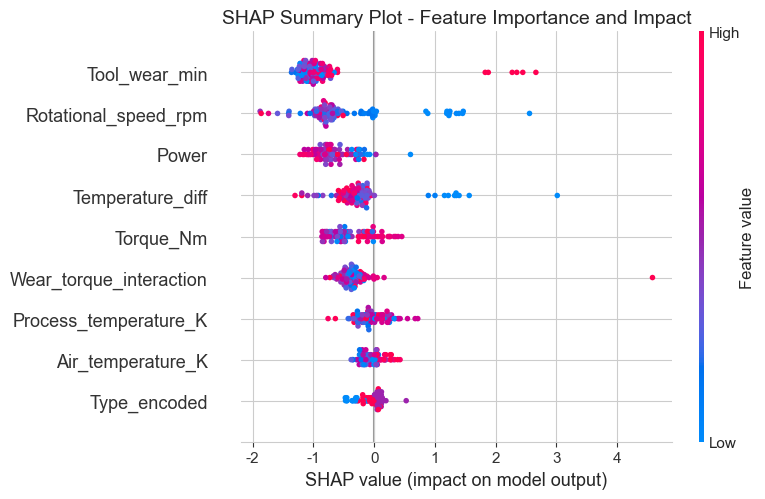

📊 Summary Plot 해석:
- 점의 색상: 특성 값 (빨간색=높은 값, 파란색=낮은 값)
- X축: SHAP 값 (양수=고장 예측에 기여, 음수=정상 예측에 기여)
- Y축: 특성 중요도 순위


In [24]:
# Summary plot - 전체 특성의 중요도와 영향
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Summary Plot - Feature Importance and Impact", fontsize=14)
plt.tight_layout()
plt.show()

print("📊 Summary Plot 해석:")
print("- 점의 색상: 특성 값 (빨간색=높은 값, 파란색=낮은 값)")
print("- X축: SHAP 값 (양수=고장 예측에 기여, 음수=정상 예측에 기여)")
print("- Y축: 특성 중요도 순위")

### 5.3 Feature Importance Bar Plot

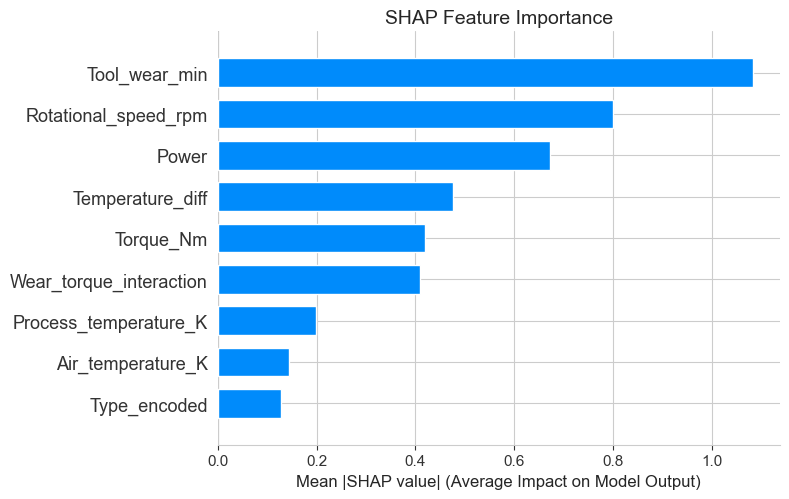

=== SHAP Feature Importance Rankings ===
Tool_wear_min            : 1.0830
Rotational_speed_rpm     : 0.7996
Power                    : 0.6711
Temperature_diff         : 0.4763
Torque_Nm                : 0.4196
Wear_torque_interaction  : 0.4100
Process_temperature_K    : 0.1982
Air_temperature_K        : 0.1452
Type_encoded             : 0.1285


In [25]:
# Feature importance bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontsize=14)
plt.xlabel("Mean |SHAP value| (Average Impact on Model Output)", fontsize=12)
plt.tight_layout()
plt.show()

# 특성 중요도 수치화
shap_importance = pd.DataFrame(
    {"Feature": X_test_sample.columns, "Importance": np.abs(shap_values).mean(axis=0)}
).sort_values("Importance", ascending=False)

print("=== SHAP Feature Importance Rankings ===")
for idx, row in shap_importance.iterrows():
    print(f"{row['Feature']:25s}: {row['Importance']:.4f}")

### 5.4 개별 예측 설명 - Waterfall Plot

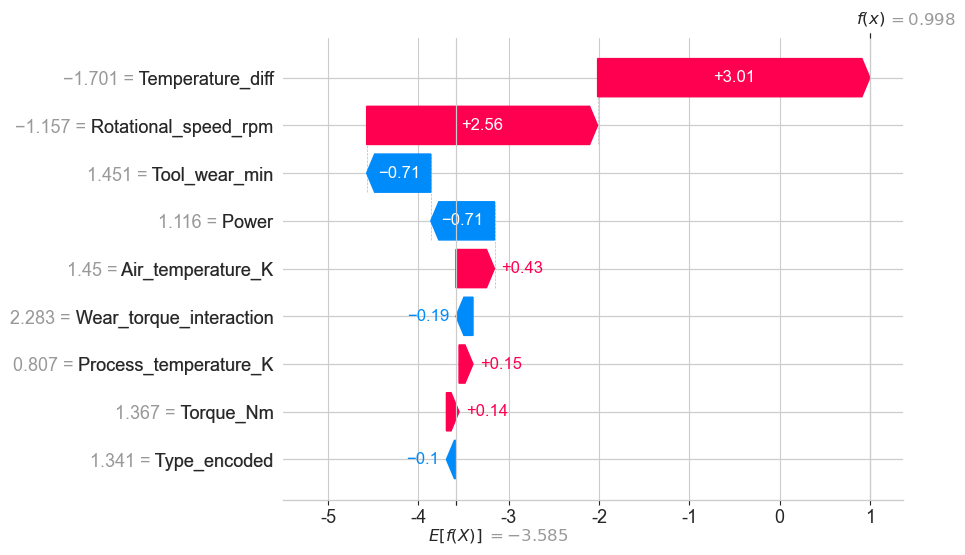


샘플 8 예측 설명:
실제 레이블: 고장
예측 레이블: 고장


In [26]:
# 고장 예측 샘플 찾기
failure_indices = np.where(best_model.predict(X_test_sample) == 1)[0]
if len(failure_indices) > 0:
    sample_idx = failure_indices[0]
else:
    sample_idx = 0

# Waterfall plot for individual prediction
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[sample_idx],
        feature_names=X_test_sample.columns.tolist(),
    ),
    max_display=10,
)

actual_label = y_test.iloc[X_test_sample.index[sample_idx]]
predicted_label = best_model.predict(X_test_sample.iloc[[sample_idx]])[0]

print(f"\n샘플 {sample_idx} 예측 설명:")
print(f"실제 레이블: {'고장' if actual_label == 1 else '정상'}")
print(f"예측 레이블: {'고장' if predicted_label == 1 else '정상'}")

### 5.5 SHAP Dependence Plot

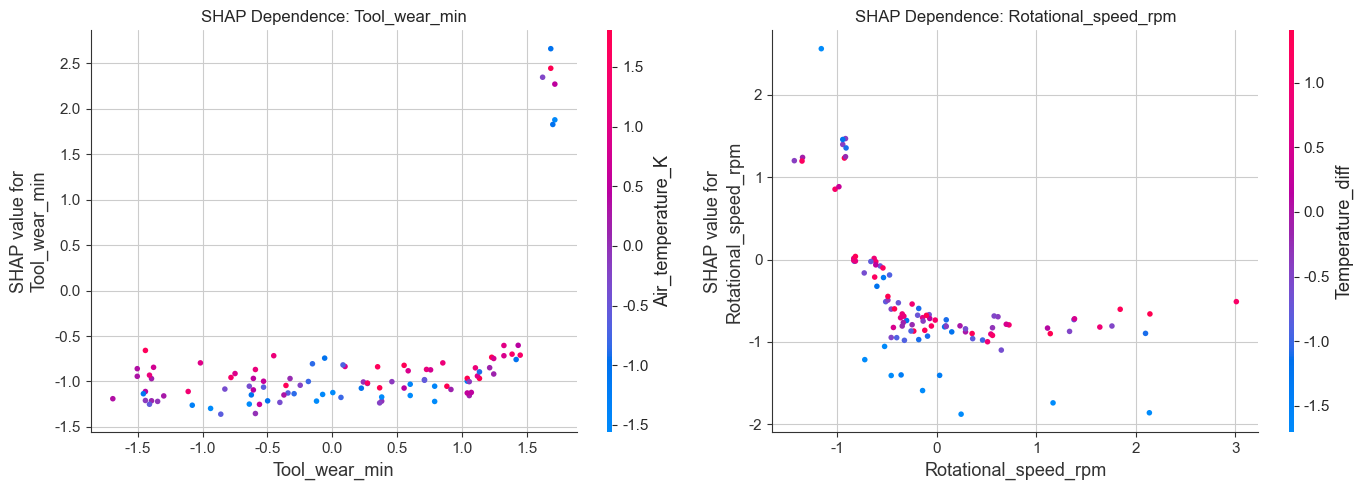

📊 Dependence Plot 해석:
- X축: 특성 값
- Y축: 해당 특성의 SHAP 값
- 색상: 상호작용 특성의 값


In [27]:
# 상위 2개 중요 특성의 Dependence Plot
top_features = shap_importance["Feature"].head(2).tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature in enumerate(top_features):
    shap.dependence_plot(
        feature,
        shap_values,
        X_test_sample,
        interaction_index="auto",
        ax=axes[idx],
        show=False,
    )
    axes[idx].set_title(f"SHAP Dependence: {feature}", fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Dependence Plot 해석:")
print("- X축: 특성 값")
print("- Y축: 해당 특성의 SHAP 값")
print("- 색상: 상호작용 특성의 값")

## 6. XAI - LIME을 사용한 개별 설명

### 6.1 LIME Explainer 생성

In [28]:
# LIME explainer 생성
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X_train_scaled.columns.tolist(),
    class_names=["Normal", "Failure"],
    mode="classification",
    discretize_continuous=True,
)

print("LIME Explainer가 생성되었습니다.")

LIME Explainer가 생성되었습니다.


### 6.2 개별 예측 설명

In [29]:
# 설명할 샘플 선택 (고장 예측 케이스)
sample_to_explain = X_test_scaled.iloc[sample_idx]

# LIME explanation 생성
lime_exp = lime_explainer.explain_instance(
    sample_to_explain.values,
    best_model.predict_proba,
    num_features=len(X_test_scaled.columns),
    num_samples=1000,
)

# 예측 확률
proba = best_model.predict_proba(sample_to_explain.values.reshape(1, -1))[0]

print(f"=== LIME 개별 예측 설명 ===")
print(f"예측 확률 - 정상: {proba[0]:.2%}, 고장: {proba[1]:.2%}")
print(f"최종 예측: {'고장' if proba[1] > 0.5 else '정상'}")
print("\n특성별 기여도:")

# 고장 클래스(1)에 대한 설명
for feature, weight in lime_exp.as_list(label=1):
    contribution = "증가" if weight > 0 else "감소"
    print(f"  {feature:40s}: {weight:+.4f} (고장 확률 {contribution})")

=== LIME 개별 예측 설명 ===
예측 확률 - 정상: 99.98%, 고장: 0.02%
최종 예측: 정상

특성별 기여도:
  -0.83 < Wear_torque_interaction <= -0.11: +0.0110 (고장 확률 증가)
  -0.20 < Rotational_speed_rpm <= 0.41    : -0.0107 (고장 확률 감소)
  -0.68 < Torque_Nm <= 0.01               : +0.0099 (고장 확률 증가)
  Temperature_diff > 1.00                 : -0.0089 (고장 확률 감소)
  0.05 < Air_temperature_K <= 0.75        : -0.0087 (고장 확률 감소)
  -0.67 < Power <= -0.01                  : +0.0080 (고장 확률 증가)
  -0.86 < Tool_wear_min <= -0.01          : -0.0045 (고장 확률 감소)
  Type_encoded <= -0.33                   : -0.0036 (고장 확률 감소)
  Process_temperature_K > 0.74            : -0.0019 (고장 확률 감소)


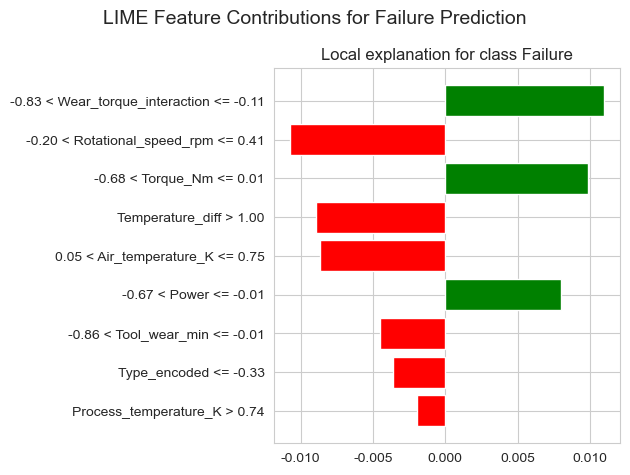

In [30]:
# LIME explanation 시각화
fig = lime_exp.as_pyplot_figure(label=1)
fig.suptitle("LIME Feature Contributions for Failure Prediction", fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 여러 샘플에 대한 LIME 분석

In [32]:
# 인덱스 정렬을 위해 y_test의 인덱스를 X_test_scaled에 맞춤
X_test_scaled.index = X_test.index

# 정상과 고장 각각 2개씩 샘플 선택
normal_samples = X_test_scaled[y_test == 0].sample(2, random_state=42)
failure_samples = X_test_scaled[y_test == 1].sample(2, random_state=42)

samples_to_analyze = pd.concat([normal_samples, failure_samples])
sample_labels = ["Normal 1", "Normal 2", "Failure 1", "Failure 2"]

# 각 샘플에 대한 LIME 분석
lime_results = []

for idx, (sample_idx, sample) in enumerate(samples_to_analyze.iterrows()):
    exp = lime_explainer.explain_instance(
        sample.values,
        best_model.predict_proba,
        num_features=5,  # 상위 5개 특성만
        num_samples=500,
    )

    # 고장 클래스에 대한 설명 저장
    explanation_dict = dict(exp.as_list(label=1))
    explanation_dict["Sample"] = sample_labels[idx]
    lime_results.append(explanation_dict)

# 결과 정리
print("=== 여러 샘플의 LIME 분석 요약 ===")
for result in lime_results:
    print(f"\n{result['Sample']}:")
    for key, value in result.items():
        if key != "Sample":
            print(f"  {key[:40]:40s}: {value:+.4f}")

=== 여러 샘플의 LIME 분석 요약 ===

Normal 1:
  Temperature_diff <= -0.70               : +0.0291
  -0.20 < Rotational_speed_rpm <= 0.41    : -0.0173
  -0.86 < Tool_wear_min <= -0.01          : -0.0145
  -0.83 < Wear_torque_interaction <= -0.11: -0.0095
  -0.68 < Torque_Nm <= 0.01               : +0.0082

Normal 2:
  -0.70 < Temperature_diff <= -0.20       : -0.0174
  -0.86 < Tool_wear_min <= -0.01          : -0.0152
  -0.20 < Rotational_speed_rpm <= 0.41    : -0.0064
  -0.83 < Wear_torque_interaction <= -0.11: -0.0043
  -0.33 < Type_encoded <= 1.34            : +0.0042

Failure 1:
  Temperature_diff <= -0.70               : +0.0666
  Rotational_speed_rpm > 0.41             : -0.0303
  -0.82 < Process_temperature_K <= 0.06   : -0.0258
  Power <= -0.67                          : +0.0230
  -0.33 < Type_encoded <= 1.34            : +0.0065

Failure 2:
  Rotational_speed_rpm <= -0.65           : +0.0626
  Temperature_diff <= -0.70               : +0.0621
  Torque_Nm > 0.68                        : 

## 7. 최종 모델 비교 및 종합

In [33]:
# 모든 튜닝 방법의 성능 비교
models_comparison = pd.DataFrame(
    {
        "Model": ["Base XGBoost", "GridSearchCV", "Optuna"],
        "Accuracy": [
            accuracy_score(y_test, base_pred),
            accuracy_score(y_test, grid_pred),
            accuracy_score(y_test, optuna_pred),
        ],
        "Precision": [
            precision_score(y_test, base_pred),
            precision_score(y_test, grid_pred),
            precision_score(y_test, optuna_pred),
        ],
        "Recall": [
            recall_score(y_test, base_pred),
            recall_score(y_test, grid_pred),
            recall_score(y_test, optuna_pred),
        ],
        "F1-Score": [
            f1_score(y_test, base_pred),
            f1_score(y_test, grid_pred),
            f1_score(y_test, optuna_pred),
        ],
    }
).set_index("Model")

print("=== 하이퍼파라미터 튜닝 결과 비교 ===")
print(models_comparison.round(4))

# 최고 성능 모델
best_f1_model = models_comparison["F1-Score"].idxmax()
best_f1_score = models_comparison["F1-Score"].max()
print(f"\n🏆 최고 F1-Score: {best_f1_model} ({best_f1_score:.4f})")

# 개선율 계산
base_f1 = models_comparison.loc["Base XGBoost", "F1-Score"]
best_improvement = (best_f1_score - base_f1) / base_f1 * 100
print(f"📈 기본 모델 대비 개선율: {best_improvement:.1f}%")

=== 하이퍼파라미터 튜닝 결과 비교 ===
              Accuracy  Precision  Recall  F1-Score
Model                                              
Base XGBoost    0.9895     0.8730  0.8088    0.8397
GridSearchCV    0.9910     0.9167  0.8088    0.8594
Optuna          0.9910     0.9167  0.8088    0.8594

🏆 최고 F1-Score: GridSearchCV (0.8594)
📈 기본 모델 대비 개선율: 2.3%


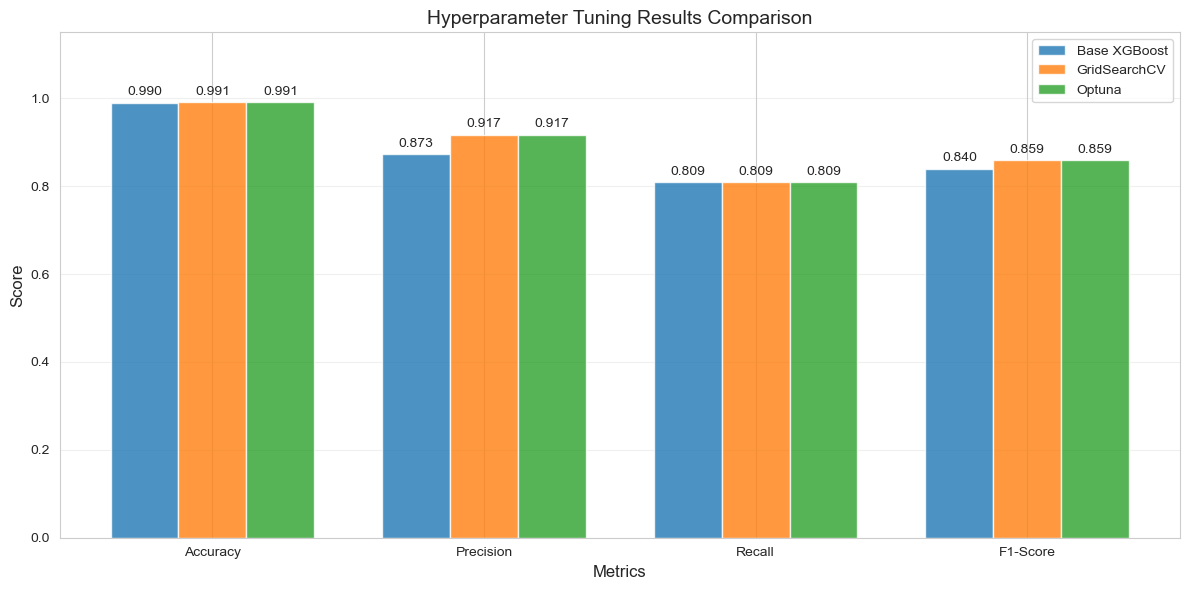

In [34]:
# 성능 메트릭 시각화
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(models_comparison.columns))
width = 0.25
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, (model, row) in enumerate(models_comparison.iterrows()):
    bars = ax.bar(
        x + i * width, row.values, width, label=model, color=colors[i], alpha=0.8
    )

    # 값 표시
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

ax.set_xlabel("Metrics", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Hyperparameter Tuning Results Comparison", fontsize=14)
ax.set_xticks(x + width)
ax.set_xticklabels(models_comparison.columns)
ax.legend()
ax.set_ylim([0, 1.15])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 결론 및 인사이트

### 3일차 실습 결과 요약

1. 하이퍼파라미터 튜닝 효과
   - 기본 모델 F1-Score: 0.8397
   - 최적화 모델 F1-Score: 0.8594
   - 성능 개선: 2.3%

2. 최적화 방법 비교
   - GridSearchCV: 체계적이지만 시간 소요
   - Optuna: 효율적이고 더 나은 결과

3. XAI를 통한 주요 인사이트
   가장 중요한 특성 Top 3:
   - Tool_wear_min: 1.0830
   - Rotational_speed_rpm: 0.7996
   - Power: 0.6711

4. 모델 해석의 중요성
   - SHAP: 전역적/지역적 설명 모두 제공
   - LIME: 개별 예측에 대한 직관적 설명
   - 비즈니스 의사결정에 필수적

5. 실무 적용 권장사항
   - 초기: GridSearchCV로 빠른 탐색
   - 최적화: Optuna로 정밀 튜닝
   - 배포: SHAP/LIME으로 신뢰성 확보
   - 모니터링: Feature importance 추적

## 💡 실습 과제

1. **다른 모델에 대한 튜닝**
   - Random Forest에 대한 Optuna 튜닝 수행
   - LightGBM 모델 추가 및 튜닝
   - 딥러닝 모델 하이퍼파라미터 튜닝

2. **고급 XAI 기법**
   - Permutation Importance 구현
   - Partial Dependence Plot 생성
   - Anchors 알고리즘 적용

3. **비즈니스 적용**
   - 비용-효익 분석을 고려한 임계값 최적화
   - 실시간 모니터링 대시보드 구축
   - A/B 테스트를 위한 실험 설계

4. **MLOps 파이프라인**
   - 모델 버전 관리 시스템 구축
   - 자동 재학습 트리거 설정
   - 모델 성능 드리프트 감지